# 🚗 Driver Behavior Anomaly Detection
## Notebook 06 — Evaluation & Prediction (Step 9 & 10)

### What we measure
| Metric | What it tells us |
|--------|-----------------|
| **Accuracy** | % of windows correctly classified |
| **Precision** | Of all "AGGRESSIVE" predictions, how many were right? |
| **Recall** | Of all actual "AGGRESSIVE" windows, how many did we catch? |
| **F1-Score** | Harmonic mean of precision & recall |
| **AUC-ROC** | Overall discrimination ability (1.0 = perfect) |

### ⚠️ Safety note
For safety-critical models (like this), **Recall** for AGGRESSIVE matters most.  
Missing an aggressive driver (false negative) is worse than a false alarm.

In [1]:
import os, warnings, pickle
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

OUTPUT_DIR   = "outputs"
CLASS_NAMES  = ["NORMAL", "AGGRESSIVE", "SLOW"]
CLASS_COLORS = {"NORMAL": "#2ecc71", "AGGRESSIVE": "#e74c3c", "SLOW": "#3498db"}
NUM_CLASSES  = 3

# Load model and test data
model  = tf.keras.models.load_model(f"{OUTPUT_DIR}/best_model.keras")
X_test = np.load(f"{OUTPUT_DIR}/X_test.npy")
y_test = np.load(f"{OUTPUT_DIR}/y_test.npy")

with open(f"{OUTPUT_DIR}/scaler.pkl", 'rb') as f:
    scaler = pickle.load(f)

print(f"✅ Model loaded")
print(f"   Test set: {X_test.shape}  ({len(y_test)} windows)")

✅ Model loaded
   Test set: (19, 50, 11)  (19 windows)


### Run predictions

In [2]:
y_pred_proba = model.predict(X_test, verbose=0)   # probabilities for each class
y_pred       = np.argmax(y_pred_proba, axis=1)    # pick highest-probability class

print("Prediction probabilities (first 5 windows):")
header = f"{'Window':>8}  {'True':>12}  {'Predicted':>12}  {'Confidence':>12}"
print(header)
print("-" * len(header))
for i in range(min(5, len(y_test))):
    true_cls  = CLASS_NAMES[y_test[i]]
    pred_cls  = CLASS_NAMES[y_pred[i]]
    conf      = y_pred_proba[i].max()
    correct   = "✅" if y_test[i] == y_pred[i] else "❌"
    print(f"{correct} {i:>6}  {true_cls:>12}  {pred_cls:>12}  {conf:>12.3f}")

Prediction probabilities (first 5 windows):
  Window          True     Predicted    Confidence
--------------------------------------------------
✅      0          SLOW          SLOW         0.716
✅      1    AGGRESSIVE    AGGRESSIVE         0.714
❌      2        NORMAL          SLOW         0.600
✅      3          SLOW          SLOW         0.596
✅      4          SLOW          SLOW         0.698


### Overall test metrics

In [3]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print()
print("Per-class Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

  Test Loss     : 0.7411
  Test Accuracy : 68.42%

Per-class Classification Report:
              precision    recall  f1-score   support

      NORMAL     1.0000    0.1667    0.2857         6
  AGGRESSIVE     0.6250    1.0000    0.7692         5
        SLOW     0.7000    0.8750    0.7778         8

    accuracy                         0.6842        19
   macro avg     0.7750    0.6806    0.6109        19
weighted avg     0.7750    0.6842    0.6201        19



### Confusion Matrix

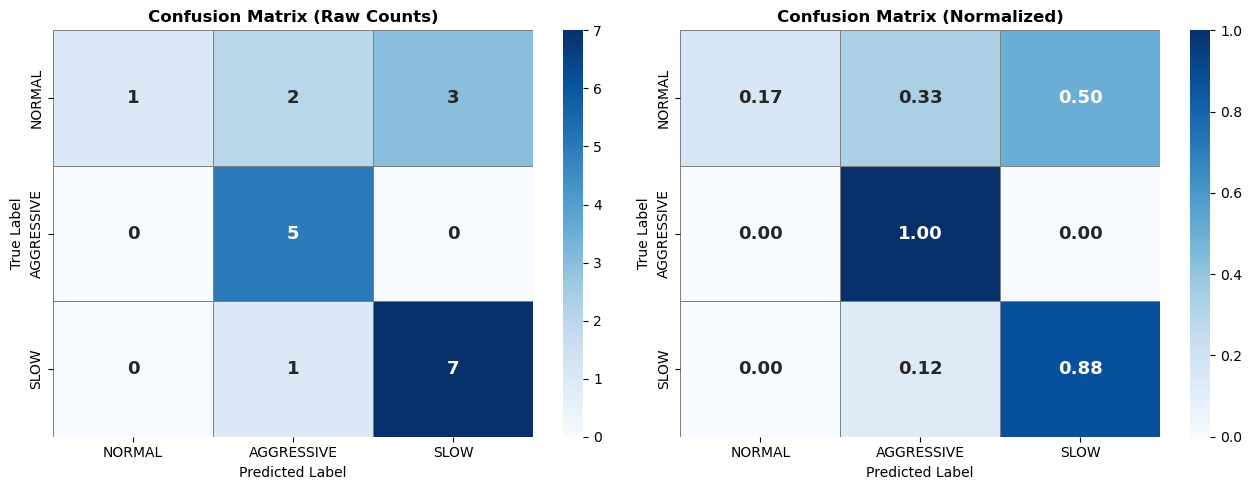

In [4]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, matrix, title, fmt in zip(axes,
        [cm, cm_norm],
        ['Confusion Matrix (Raw Counts)', 'Confusion Matrix (Normalized)'],
        ['d', '.2f']):
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray', ax=ax,
                annot_kws={'size': 13, 'fontweight': 'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves (one-vs-rest per class)

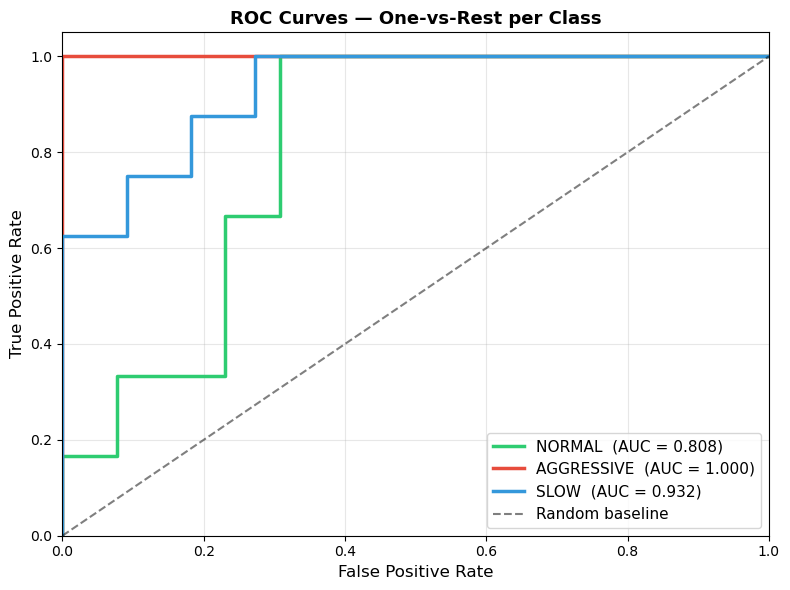

In [5]:
y_bin   = label_binarize(y_test, classes=[0, 1, 2])
colors  = ["#2ecc71", "#e74c3c", "#3498db"]

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random baseline')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("ROC Curves — One-vs-Rest per Class", fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Per-class accuracy

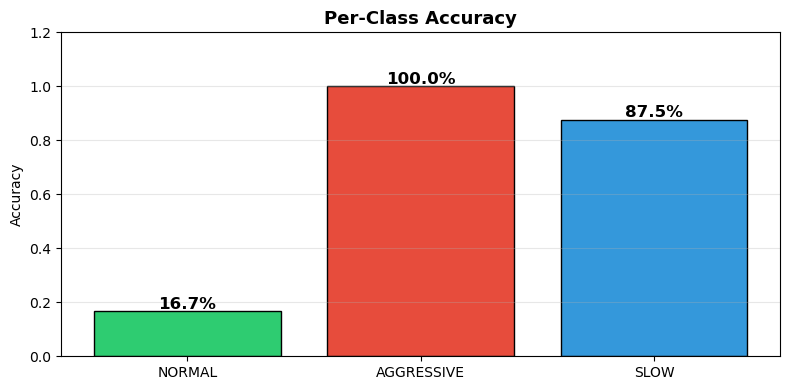

In [6]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = [CLASS_COLORS[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor='black')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{acc*100:.1f}%", ha='center', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1.2])
ax.set_title("Per-Class Accuracy", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_per_class_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

### Predict on unlabeled data (`test_motion_data_nolabels.csv`)

In [7]:
# Load + preprocess unlabeled CSV
df_un = pd.read_csv("test_motion_data_nolabels.csv")
df_un = df_un.sort_values('Timestamp').reset_index(drop=True)

SENSOR_COLS = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ"]
SAMPLING_RATE = 10

# Feature engineering (same as Notebook 02)
df_un['jerk_x']        = df_un['AccX'].diff().fillna(0) * SAMPLING_RATE
df_un['jerk_y']        = df_un['AccY'].diff().fillna(0) * SAMPLING_RATE
df_un['jerk_z']        = df_un['AccZ'].diff().fillna(0) * SAMPLING_RATE
df_un['lateral_qforce'] = np.sqrt(df_un['AccX']**2 + df_un['AccY']**2)
acc_mag = np.sqrt(df_un['AccX']**2 + df_un['AccY']**2 + df_un['AccZ']**2)
df_un['speed_variance'] = acc_mag.rolling(50, min_periods=1).var().fillna(0)
df_un['label'] = 0  # dummy label for windowing

ALL_FEATURES = SENSOR_COLS + ['jerk_x','jerk_y','jerk_z','lateral_qforce','speed_variance']

# Windowing (same as Notebook 03)
from collections import Counter
X_un_list = []
vals   = df_un[ALL_FEATURES].values.astype(np.float32)
labels = df_un['label'].values.astype(np.int32)
for start in range(0, len(vals) - 50 + 1, 25):
    X_un_list.append(vals[start:start+50])
X_un = np.array(X_un_list, dtype=np.float32)

# Normalize with the SAME scaler from training
n, T, F = X_un.shape
X_un_scaled = scaler.transform(X_un.reshape(-1, F)).reshape(n, T, F)

print(f"Unlabeled windows: {X_un_scaled.shape}")

Unlabeled windows: (122, 50, 11)


In [8]:
# Predict
proba  = model.predict(X_un_scaled, verbose=0)
pred   = np.argmax(proba, axis=1)
conf   = proba.max(axis=1)

results = pd.DataFrame({
    'window'          : range(len(pred)),
    'predicted_class' : [CLASS_NAMES[p] for p in pred],
    'confidence'      : conf.round(4),
    'prob_NORMAL'     : proba[:, 0].round(4),
    'prob_AGGRESSIVE' : proba[:, 1].round(4),
    'prob_SLOW'       : proba[:, 2].round(4),
})

results.to_csv(f"{OUTPUT_DIR}/predictions_unlabeled.csv", index=False)

print("Prediction distribution:")
print(results['predicted_class'].value_counts().to_string())
print()
print("Sample predictions:")
print(results.head(10).to_string(index=False))

Prediction distribution:
predicted_class
SLOW          63
AGGRESSIVE    35
NORMAL        24

Sample predictions:
 window predicted_class  confidence  prob_NORMAL  prob_AGGRESSIVE  prob_SLOW
      0      AGGRESSIVE      0.8346       0.0744           0.8346     0.0910
      1      AGGRESSIVE      0.4777       0.2203           0.4777     0.3021
      2      AGGRESSIVE      0.6335       0.1559           0.6335     0.2105
      3      AGGRESSIVE      0.6457       0.1931           0.6457     0.1612
      4      AGGRESSIVE      0.5612       0.1567           0.5612     0.2822
      5      AGGRESSIVE      0.6290       0.1564           0.6290     0.2146
      6      AGGRESSIVE      0.5733       0.2492           0.5733     0.1774
      7      AGGRESSIVE      0.7990       0.1022           0.7990     0.0988
      8      AGGRESSIVE      0.8299       0.0851           0.8299     0.0850
      9      AGGRESSIVE      0.8969       0.0481           0.8969     0.0550


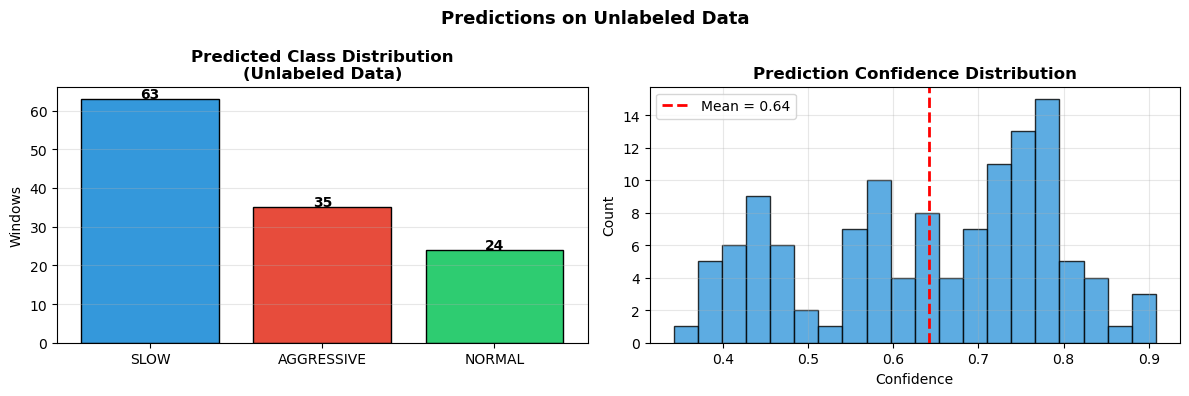


Mean prediction confidence: 0.642


In [9]:
# Visualise prediction distribution
counts = results['predicted_class'].value_counts()
colors = [CLASS_COLORS[c] for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(cnt), ha='center', fontweight='bold')
axes[0].set_title("Predicted Class Distribution\n(Unlabeled Data)", fontweight='bold')
axes[0].set_ylabel("Windows"); axes[0].grid(axis='y', alpha=0.3)

# Confidence distribution
axes[1].hist(results['confidence'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].axvline(results['confidence'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean = {results['confidence'].mean():.2f}")
axes[1].set_title("Prediction Confidence Distribution", fontweight='bold')
axes[1].set_xlabel("Confidence"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Predictions on Unlabeled Data", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean prediction confidence: {results['confidence'].mean():.3f}")

### Save full report

In [10]:
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4)
with open(f"{OUTPUT_DIR}/classification_report.txt", 'w') as f:
    f.write(f"Test Accuracy : {test_acc*100:.2f}%\n")
    f.write(f"Test Loss     : {test_loss:.4f}\n\n")
    f.write(report)

print("✅ Full project outputs saved to outputs/:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"   {fname:<45}  {size:>8,} bytes")

✅ Full project outputs saved to outputs/:
   01_class_distribution.png                        72,276 bytes
   01_correlation.png                               79,238 bytes
   01_raw_signals.png                              553,487 bytes
   01_sensor_boxplots.png                          163,485 bytes
   02_derived_features.png                         100,837 bytes
   03_sample_windows.png                           594,183 bytes
   03_window_distribution.png                       35,351 bytes
   04_smote.png                                     38,698 bytes
   05_training_curves.png                           87,924 bytes
   06_confusion_matrix.png                          62,956 bytes
   06_per_class_accuracy.png                        32,461 bytes
   06_predictions.png                               67,418 bytes
   06_roc_curves.png                                76,504 bytes
   X_test.npy                                       41,928 bytes
   X_train.npy                                  

---
## 🎉 Project Complete!

### Summary
| Step | What we did |
|------|-------------|
| 01 | Explored sensor data — 3 classes, 3084 samples |
| 02 | Added Jerk, Lateral Q-force, Speed Variance features |
| 03 | Created 5-second sliding windows (50% overlap) |
| 04 | Balanced with SMOTE, normalized with StandardScaler |
| 05 | Trained CNN-LSTM hybrid (92K params, 60 epochs) |
| 06 | Evaluated with confusion matrix, ROC, per-class accuracy |
